In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm
from scipy.special import ndtri
from scipy.optimize import brentq
from typing import Any

from common import bsm_put, result, erreur_multiplicative, get_beta

In [2]:
class Bates:
    def __init__(self, S0: float, r: float, lbda: float, mu_z: float, sigma_z: float, v0: float, kappa: float, theta: float, xi: float, rho: float, T: float, N: int, K: float, no_neg: str) -> None:
        self.S0 = S0
        self.r = r
        self.lbda = lbda
        self.mu_z = mu_z
        self.sigma_z = sigma_z
        self.v0 = v0
        self.kappa = kappa
        self.theta = theta
        self.xi = xi
        self.rho = rho
        self.T = T
        self.N = N
        self.K=K

        self.dt = T / N

        self.fct_no_neg_choose(no_neg)
        self.mu_a = np.exp(self.mu_z + self.sigma_z**2 / 2)

    def fct_no_neg_choose(self, name: str) -> None:
        if name == "absorbant":
            self.fct_no_neg = lambda x,v_t: max(x,0)
        elif name == "reflexif":
            self.fct_no_neg = lambda x,v_t: abs(x)
        elif name == "qe":
            self.fct_no_neg="qe"
        elif name == "tg":
            self.fct_no_neg="tg"
            #raise ValueError("pas encore fait")
        else:
            raise ValueError("bad fct no_neg name")

    def simulate_brownian(self) -> None:
        Z = np.random.multivariate_normal(mean=[0, 0],
                                           cov=np.array([[1, self.rho], [self.rho, 1]]),
                                           size=self.N)

        self.dW1, self.dW2 = Z[:, 0] * np.sqrt(self.dt), Z[:, 1] * np.sqrt(self.dt)

    def simulate_BSM(self) -> None:
        if not hasattr(self, "dW1") or not hasattr(self, "dW2"):
            self.simulate_brownian()
        #theta c la variance a long terme dans le model de heston donc
        self.S_BSM=self.S0*np.exp((self.r-self.theta/2)*self.dt+np.sqrt(self.theta)*self.dW1).cumprod()

    def simulate_volatility(self) -> None:
        if not hasattr(self, "dW1") or not hasattr(self, "dW2"):
            self.simulate_brownian()
        v = [self.v0]
        if type(self.fct_no_neg) == "function":
            for i in range(self.N - 1):
                v.append(self.fct_no_neg(v[-1] +
                                         (self.kappa * (self.theta - v[-1]) * self.dt +
                                          self.xi * np.sqrt(v[-1]) * self.dW2[i]),v[-1]))
        else:
            if self.fct_no_neg == "qe":
                truc_kappa=np.exp(-self.kappa*self.dt)
                U_v=norm.cdf(self.dW2/np.sqrt(dt)) #garder correl
                psi_c = 1.5
                for i in range(self.N-1):
                    m=self.theta+(v[-1]-self.theta)*truc_kappa
                    s2=(v[-1]*self.xi**2*truc_kappa)/self.kappa * (1-truc_kappa) + (self.theta * self.xi**2)/(2*self.kappa) * (1-truc_kappa)**2
                    psi = s2/m**2
                    if psi <= psi_c:
                        b2=2/psi-1+np.sqrt(2/psi) * np.sqrt(2/psi-1)
                        a=m/(1+b2)
                        z_v=ndtri(U_v[i])
                        v.append(a*(np.sqrt(b2)+z_v)**2)
                    else:
                        p=(psi-1)/(psi+1)
                        beta=(1-p)/m
                        if 0<=U_v[i]<=p:
                            v.append(0)
                        elif p < U_v[i] <= 1:
                            v.append(np.log((1-p)/(1-U_v[i]))/beta)
            elif self.fct_no_neg == "tg":
                for i in range(self.N-1):
                    alpha=5
                    exp_kdt = np.exp(-self.kappa*self.dt)
                    eps=1e-12

                    m = theta + (v[-1] - self.theta) * exp_kdt

                    s2 = (eps**2 * v[-1] * exp_kdt / self.kappa) * (1-exp_kdt) \
                       + (eps**2 * self.theta / (2*self.kappa)) * (1-exp_kdt)**2

                    s=np.sqrt(s2)

                    if m/s > alpha:
                        mu=m
                        sigma=s
                    else:
                        psi=s2/(m**2)

                        def f(r):
                            return (
                                r*norm.pdf(r) + norm.cdf(r)*(1+r*r)
                                - (1+psi)*(norm.pdf(r)+r*norm.cdf(r))**2
                            )
                        r = brentq(f, -50.0, 50.0)
                        denom = norm.pdf(r) + r*norm.cdf(r)

                        mu=m*r/denom
                        sigma=s/denom

                    Z=np.random.normal()
                    v.append(max(0.0,mu+sigma*Z))

        self.v = np.array(v)

    def simulate_jumps(self) -> None:
        self.dN = np.random.poisson(self.lbda * self.dt, size=self.N)
        self.dJ= self.dN * (np.exp(self.mu_z + self.sigma_z * np.random.normal(0, 1, size=self.N)) - 1)

    def simulate_put_conditional(self) -> None:
        if not hasattr(self, "v"):
            self.simulate_volatility()
        if not hasattr(self, "dJ"):
            self.simulate_jumps()
        n=self.dN.sum()
        bar_S0_n=self.S0*np.exp(-self.lbda*(self.mu_a-1)*self.T+n*self.mu_z+0.5*n*self.sigma_z**2)
        sigma_T_n=(self.v).sum()*self.dt+n*self.sigma_z**2
        self.put_cond=bsm_put(bar_S0_n,self.K, self.r,np.sqrt(sigma_T_n/self.T), self.T,0)

    def simulate_S(self) -> None:
        if not hasattr(self, "v"):
            self.simulate_volatility()
        if not hasattr(self, "dJ"):
            self.simulate_jumps()

        self.S = 1 + (self.r - self.lbda * (self.mu_a - 1)) * self.dt + np.sqrt(self.v) * self.dW1 + self.dJ
        self.S = self.S0 * np.cumprod(self.S)

def put_bates(S0: float, r: float, lbda: float, mu_z: float, sigma_z: float, v0: float, kappa: float, theta: float, xi: float, rho: float, T: float, N: int, K: float, no_neg: str = "qe", n: int = 1000) -> float:
    put_cond=[]
    for i in range(n):
        model=Bates(S0=S0, r=r, lbda=lbda, mu_z=mu_z, sigma_z=sigma_z,v0=v0, kappa=kappa, theta=theta, xi=xi, rho=rho, T=T, N=N,K=K,no_neg=no_neg)
        model.simulate_brownian()
        model.simulate_jumps()
        model.simulate_BSM()
        model.simulate_put_conditional()
        put_cond.append(model.put_cond)
    put_cond=np.array(put_cond)
    return put_cond.mean()

def sensi(default_params: dict[str, Any], param: np.ndarray, var: str) -> None:
    result=[]
    for i in param:
        params=""
        default=default_params.copy()
        del default[var]
        for j in default:
            params+=f"{j}={default[j]},"
        params+=f"{var}={i}"
        eval(f"result.append(put_bates({params}))")
    plt.plot(param,result)
    plt.show()

def price_put_romberg_richadson_2(S0: float, r: float, lbda: float, mu_z: float, sigma_z: float, v0: float, kappa: float, theta: float, xi: float, rho: float, T: float, N: int, K: float, no_neg: str, n: int) -> tuple[float, float, float]:
    P_N = put_bates(
        S0, r, lbda, mu_z, sigma_z,
        v0, kappa, theta, xi, rho,
        T, N, K, no_neg, n
    )

    P_2N = put_bates(
        S0, r, lbda, mu_z, sigma_z,
        v0, kappa, theta, xi, rho,
        T, 2*N, K, no_neg, n
    )

    # Richardson niveau 2 (p = 1)
    P_RR = 2 * P_2N - P_N

    return P_RR, P_N, P_2N

In [3]:
S0 = 1
r = 0.02
lbda= 4
mu_z= 0.1
sigma_z = 0.3
v0 = 0.05
kappa= 0.03
theta= 0.07
xi= 0.25
rho= -0.5
T=5
K=1.05

N=1000
dt=T/N
t=np.arange(dt,T+dt,dt)
actualisation=np.exp(-r*t)

In [4]:
no_neg_method=['absorbant','reflexif','qe','tg']

#simulation avec les meme donné (meme brownien et jump) y a que la methode pour empecher negatif de v_t qui change

m=10000
S=[[] for i in range(len(no_neg_method))]
S_BSM=[]
put_cond=[]

for i in range(m):
    model=Bates(S0=S0, r=r, lbda=lbda, mu_z=mu_z, sigma_z=sigma_z,v0=v0, kappa=kappa, theta=theta, xi=xi, rho=rho, T=T, N=N, K=K,no_neg="absorbant")
    model.simulate_brownian()
    model.simulate_jumps()
    model.simulate_BSM()
    model.simulate_put_conditional()
    S_BSM.append(model.S_BSM)
    put_cond.append(model.put_cond)
    for j in range(len(no_neg_method)):
        model.fct_no_neg_choose(no_neg_method[j])
        model.simulate_volatility()
        model.simulate_S()
        S[j].append(model.S)
S=np.array(S)
S_BSM=np.array(S_BSM)
put_cond=np.array(put_cond).reshape(m,1)
for i in range(len(S)):
    S[i]=np.array(S[i])

# 5.1 Diffusion du sous-jacent

------------------------------
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
esperance: 1.132732577935611
std: 4.944339276756404
erreur multiplicative: 0.12463292412073278
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
esperance: 1.132732577935611
std: 4.944339276756404
erreur multiplicative: 0.12463292412073278
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
esperance: 1.1273893320332684
std: 4.558921657591582
erreur multiplicative: 0.1199046341700347
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
esperance: 1.1326536284109459
std: 4.966712845669763
erreur multiplicative: 0.1245632234008503
------------------------------


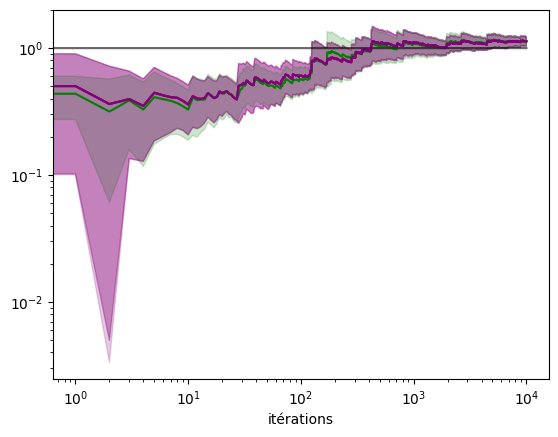

In [5]:
result(S,1)

erreur multiplicative en valeur absolue


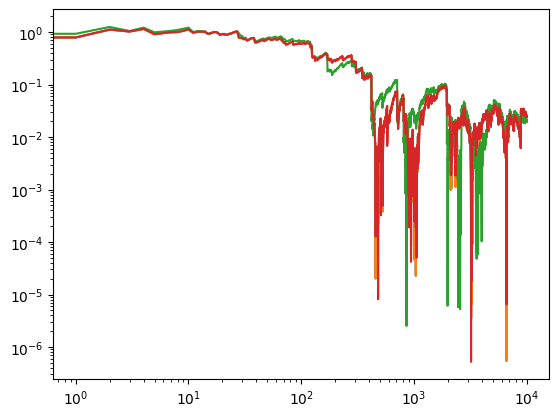

In [6]:
print("erreur multiplicative en valeur absolue")
plt.yscale('log')
plt.xscale('log')
for i in S:
    plt.plot(np.abs(erreur_multiplicative(i.transpose()[-1].cumsum()/np.arange(1,m+1)*actualisation[-1],S0)))

In [7]:
print("erreur put multiplicative")

for i in S:
    print(np.log(np.mean(i.transpose()[-1])*actualisation[-1])-np.log(S0))

erreur put multiplicative
0.024632924120730988
0.024632924120730988
0.019904634170033082
0.024563223400849914


In [8]:
print("pourcentage de temps ou les fct no negative sont les meilleur")
tmp=np.abs(np.log(S.transpose()[-1].cumsum(axis=0)/np.tile(np.arange(1,m+1)[:, np.newaxis], (1, 4))*actualisation[-1])-np.log(S0))
_result = np.zeros_like(tmp)
indexes = np.argmin(tmp, axis=1)  # Obtenir l'index de la valeur minimale pour chaque ligne
_result[np.arange(tmp.shape[0]), indexes] = 1
print(_result.sum(axis=0)/m)

pourcentage de temps ou les fct no negative sont les meilleur
[0.3932 0.     0.3102 0.2966]


# 5.2 Pricing de Put

In [9]:
print("valeur des put")
for i in S:
    print(np.mean(np.maximum(K-i.transpose()[-1],0))*actualisation[-1])

valeur des put
0.5450001783990002
0.5450001783990002
0.540688942430295
0.5456855836207724


In [10]:
print("valeur du put conditionnement")
put_cond.mean()

valeur du put conditionnement


np.float64(0.5175578105869003)

In [11]:
#pour reduire le biais de la variable de controle
biais=np.mean(S_BSM.transpose()[-1]*actualisation[-1])-bsm_put(S0,K,r,np.sqrt(theta),T,0)

In [12]:
#calcul des variable control
control=(S_BSM.transpose()[-1]*actualisation[-1]-bsm_put(S0,K,r,np.sqrt(theta),T,0)).reshape(m,1)-biais
var=np.maximum(K-S.transpose()[-1],0)*actualisation[-1]

In [13]:
beta = np.array([get_beta(var.transpose()[i].reshape(m, 1), control) for i in range(var.shape[-1])]).transpose()[0]

------------------------------
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
esperance: 0.5406889424302957
std: 0.3515782672247343
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
esperance: 0.5406620739425306
std: 0.3461057483972833
xxxxxxxxxxxxxxxxxxxxxxxxxxxxxx
esperance: 0.5175578105868882
std: 0.1056351696704303
------------------------------


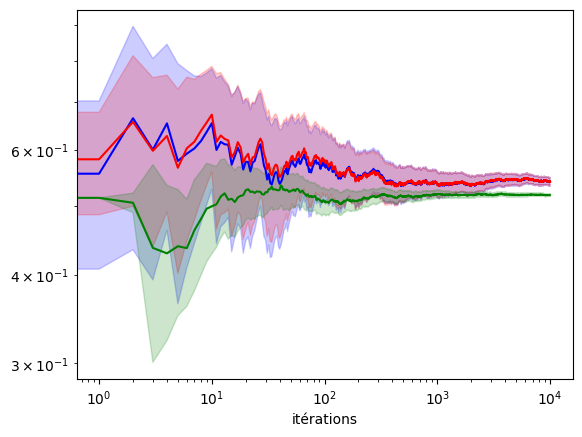

In [14]:
#on prend le 3eme car c'est qe est qu'il est meilleur que absorbant et reflexif
result(np.array([var.transpose()[2].reshape(m,1),(var-beta*control).transpose()[2].reshape(m,1),put_cond]))

# 5.3 Variations et significativités

In [15]:
default_params={"S0":S0, "r":r, "lbda":lbda, "mu_z":mu_z, "sigma_z":sigma_z,"v0":v0, "kappa":kappa, "theta":theta, "xi":xi, "rho":rho, "T":T, "N":N, "K":K}

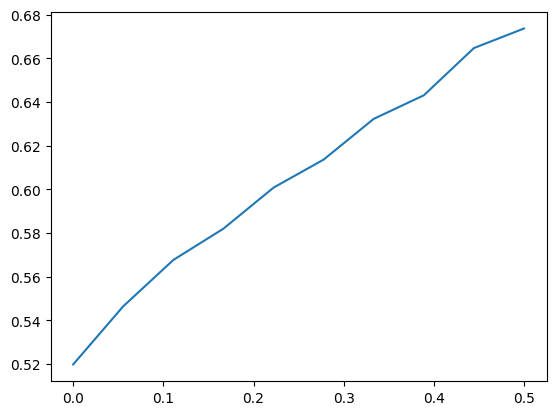

In [16]:
sensi(default_params,np.linspace(0,0.5,10),"v0")

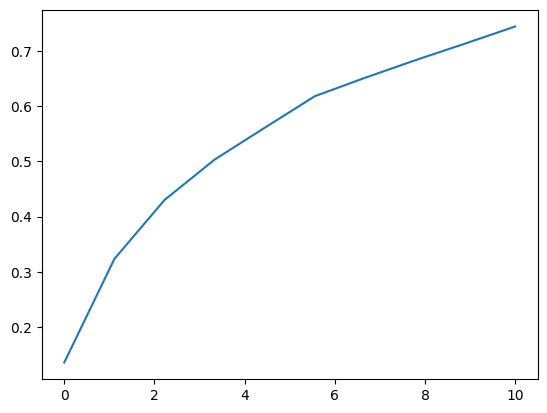

In [17]:
sensi(default_params,np.linspace(0,10,10),"lbda")

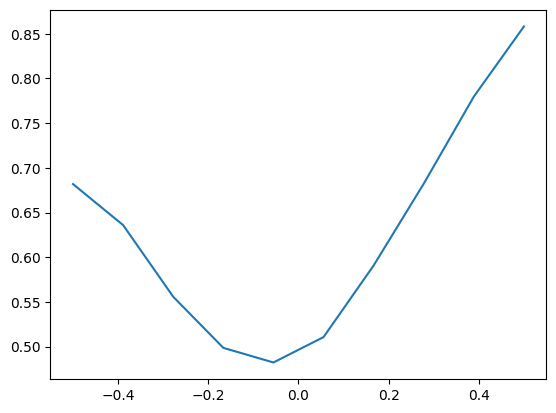

In [18]:
sensi(default_params,np.linspace(-0.5,0.5,10),"mu_z")

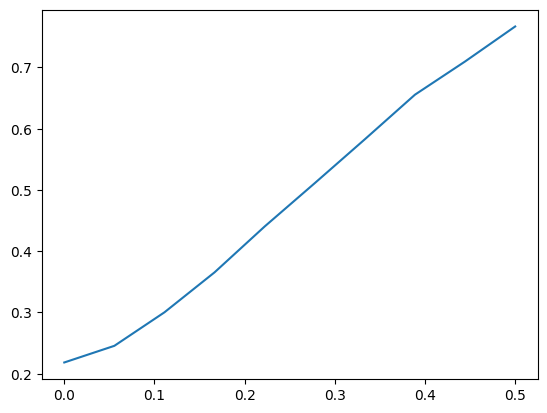

In [19]:
sensi(default_params,np.linspace(0,0.5,10),"sigma_z")

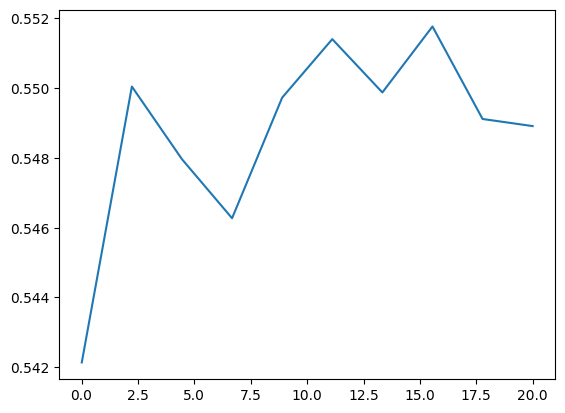

In [20]:
sensi(default_params,np.linspace(0.01,20,10),"kappa")

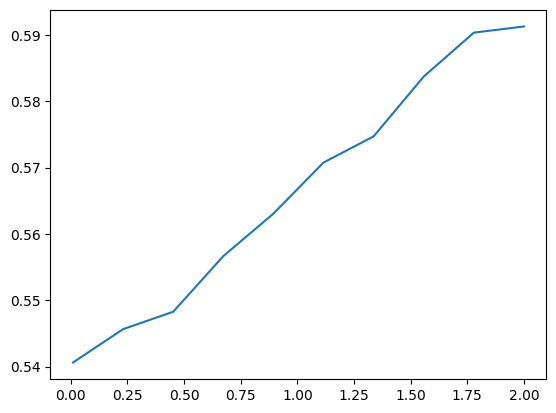

In [21]:
sensi(default_params,np.linspace(0.01,2,10),"theta")

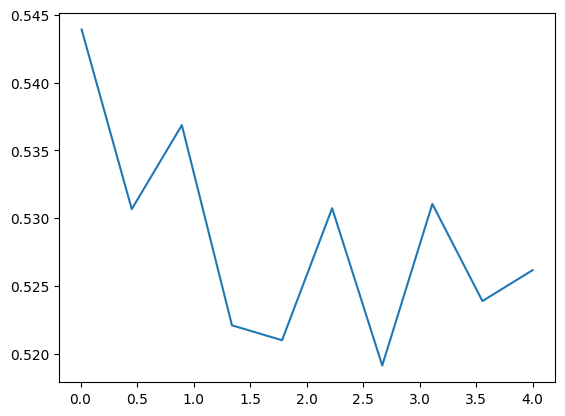

In [22]:
sensi(default_params,np.linspace(0.01,4,10),"xi")

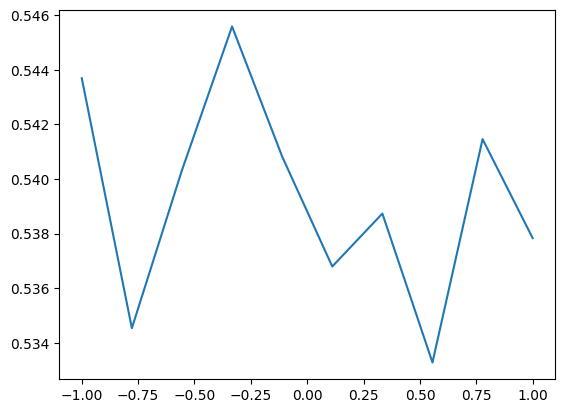

In [23]:
sensi(default_params,np.linspace(-1,1,10),"rho")

# 5.4 Réduction du biais

In [24]:
P_RR, P_N, P_2N = price_put_romberg_richadson_2(
    S0=S0, r=r, lbda=lbda, mu_z=mu_z, sigma_z=sigma_z,
    v0=v0, kappa=kappa, theta=theta, xi=xi, rho=rho,
    T=T, N=N, K=K, no_neg="reflexif", n=10000
)

print("P_N    =", P_N)
print("P_2N   =", P_2N)
print("P_RR   =", P_RR)

P_N    = 0.5200523482802403
P_2N   = 0.5184005166927834
P_RR   = 0.5167486851053266
